# Chapter 6: Scaling & Transformations

In [1]:
import pandas as pd
import numpy as np
from sklearn import preprocessing
import matplotlib as mpl
import matplotlib.pyplot as plt

## 6.1: Introduction

During this exercise you will make your own scaling function(s). We will aply this to the hepathlon dataset of the Tokyo 2020 olympics which Nafi Thiam obviously won.
 
You will explore the different scaling and normalization methods by visualising subsets of the data, after which you will make one big visualization to make some conclusons!

## 6.2: Data cleaning

There are a few issues with missing values in the data. Find the problems and fix them before we start. You can leave the missing values as NaN's for now.

*Hint: You don't have to manually fix these, you can use the pandas.read_csv function to fix everything the moment you read the file with the na_values option. Look online to see how this works or just try it.*

In [6]:
Tokyo2020 = pd.read_csv("Tokyo_2020_hepathlon.txt", sep = ";")
Tokyo2020.head()

,Rank,Country,Name,Final_Points,100m_hurdles_Result,100m_hurdles_Points,200m_Result,200m_Points,800m_Result,800m_Points,High_jump_Result,High_jump_Points,Javelin_Result,Javelin_Points,Long_jump_Result,Long_jump_Points,Shot_put_Result,Shot_put_Points
0,1.0,BEL,THIAM Nafissatou,6791,13.54,1044,24.90,896,2:15.98,879,1.92,1132,54.68,951,6.60,1040,14.82,849
1,2.0,NED,VETTER Anouk,6689,13.09,1111,23.81,999,2:18.72,841,1.8,978,51.2,883,6.47,997,15.29,880
2,3.0,NED,OOSTERWEGEL Emma,6590,13.36,1071,24.25,957,2:11.09,949,1.8,978,54.6,949,6.29,940,13.28,746
3,4.0,BEL,VIDTS Noor,6571,13.17,1099,23.70,1010,2:09.05,979,1.83,1016,41.8,702,6.32,949,14.33,816
4,5.0,USA,WILLIAMS Kendell,6508,12.97,1129,24.00,981,2:16.91,866,1.8,978,48.78,836,6.57,1030,12.41,688


In [8]:
Tokyo2020 = pd.read_csv("Tokyo_2020_hepathlon.txt", sep = ";", na_values = ['DNS', 'DNF'])
Tokyo2020.head()

,Rank,Country,Name,Final_Points,100m_hurdles_Result,100m_hurdles_Points,200m_Result,200m_Points,800m_Result,800m_Points,High_jump_Result,High_jump_Points,Javelin_Result,Javelin_Points,Long_jump_Result,Long_jump_Points,Shot_put_Result,Shot_put_Points
0,1.0,BEL,THIAM Nafissatou,6791.0,13.54,1044,24.90,896,2:15.98,879,1.92,1132,54.68,951,6.60,1040,14.82,849
1,2.0,NED,VETTER Anouk,6689.0,13.09,1111,23.81,999,2:18.72,841,1.80,978,51.20,883,6.47,997,15.29,880
2,3.0,NED,OOSTERWEGEL Emma,6590.0,13.36,1071,24.25,957,2:11.09,949,1.80,978,54.60,949,6.29,940,13.28,746
3,4.0,BEL,VIDTS Noor,6571.0,13.17,1099,23.70,1010,2:09.05,979,1.83,1016,41.80,702,6.32,949,14.33,816
4,5.0,USA,WILLIAMS Kendell,6508.0,12.97,1129,24.00,981,2:16.91,866,1.80,978,48.78,836,6.57,1030,12.41,688


## 6.3 Data centering

Create a function which can receive data as input, and which returns the centered data. If you do not remember what centering is, look at the slides of the corresponding lesson.

1. Create a function to center data. Make sure to first clean out any missing values!
2. Center the Javelin Result. 
3. Visualise the centered Javelin results. Make a plot with two subplots: one showing the original histogram and one showing the centered histogram.

In [23]:
def EnhanceData(data):
    data = data.dropna()
    
    data_center = data.mean()
    data_centralised = data - data_center
    
    return data_centralised

In [24]:
centered_javelin = EnhanceData(Tokyo2020['Javelin_Result'])
centered_javelin.mean()

-4.618527782440651e-15

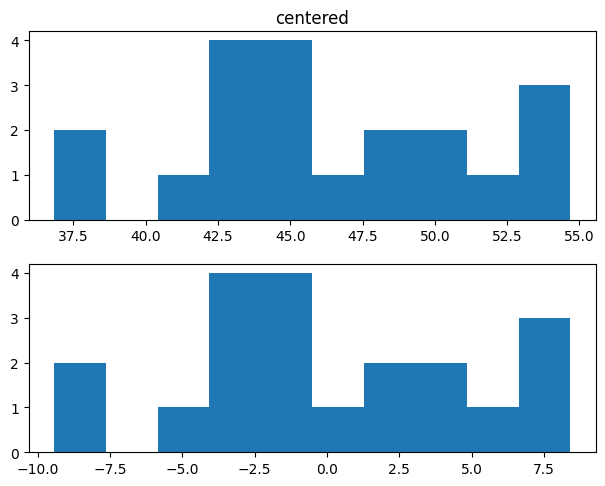

In [25]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharey=True)
fig.tight_layout()
ax1.set_title('original')
ax1.hist(Tokyo2020['Javelin_Result'])
ax1.set_title('centered')
ax2.hist(centered_javelin)
plt.show()

## 6.4: Standardization (z score)


1. Create a function or update your function to calculate z-scores (i.e. to standardize data). Remember the missing values!
2. standardize the Long Jump results 
3. Visualise the standardized Long Jump Results. Once again create two subplots to show the difference between the original data and the standardized data.

In [26]:
def EnhanceData(data, technique = ''):
    data = data.dropna()
    
    data_to_scale = data.values.reshape((len(data), 1))
    scaler = preprocessing.StandardScaler()
    scaler = scaler.fit(data_to_scale)
    data_normalized = scaler.transform(data_to_scale)
    
    return data_normalized

In [27]:
zscore_longJump = EnhanceData(Tokyo2020['Long_jump_Result'])
print(zscore_longJump.mean())
print(zscore_longJump.std())

1.6209256159527285e-15
0.9999999999999999


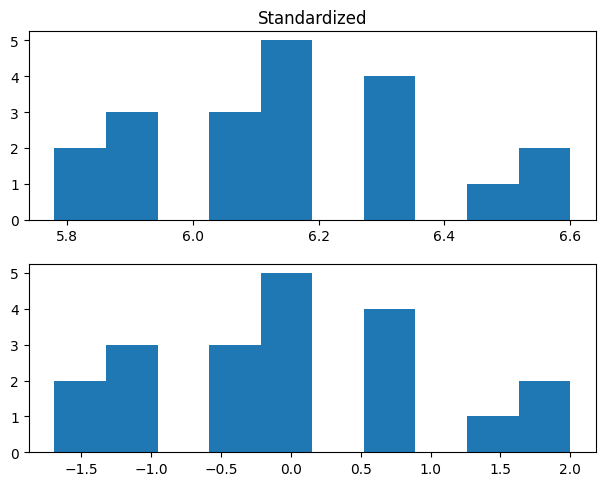

In [28]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharey=True)
fig.tight_layout()
ax1.set_title('original')
ax1.hist(Tokyo2020['Long_jump_Result'])
ax1.set_title('Standardized')
ax2.hist(zscore_longJump)
plt.show()

## 6.5: Min-Max Normalization



1. Implement Min-Max normalisation in a new or in your exsiting function. Remeber the missing values!
2. min-max normalize the Shot Put Results
3. Visualise the normalised Shot Put Results. Again, make use of two subplots.

In [31]:
def EnhanceData(data, technique = ''):
    data = data.dropna()
    
    data_to_scale = data.values.reshape((len(data), 1))
    scaler = preprocessing.MinMaxScaler()
    scaler = scaler.fit(data_to_scale)
    data_normalized = scaler.transform(data_to_scale)
    
    return data_normalized

In [33]:
minmax_shot = EnhanceData(Tokyo2020['Shot_put_Result'])
print(minmax_shot.max())
print(minmax_shot.min())

1.0
0.0


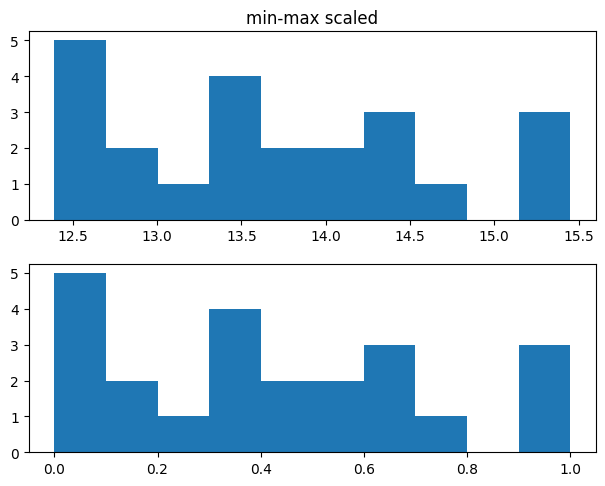

In [34]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharey=True)
fig.tight_layout()
ax1.set_title('original')
ax1.hist(Tokyo2020['Shot_put_Result'])
ax1.set_title('min-max scaled')
ax2.hist(minmax_shot)
plt.show()

## 6.6: Visualise

In this exercise you need to visualise the data for the trainer of Nafi Thiam. The trainer wants to see in a single plot, on which sports we should focus more to make sure we win next time. 

You can choose the type of plot, whether you scale, normalise or tranform the data before plotting, etc. Just make sure it is 1 visualisation which anwer the question on which sports to focus. Note, this 1 visualisation can have multiple subplots within it. 

In [132]:
Tokyo2020 = pd.read_csv("Tokyo_2020_hepathlon.txt", sep = ";", na_values = ['DNS', 'DNF'])
Tokyo2020.head()

,Rank,Country,Name,Final_Points,100m_hurdles_Result,100m_hurdles_Points,200m_Result,200m_Points,800m_Result,800m_Points,High_jump_Result,High_jump_Points,Javelin_Result,Javelin_Points,Long_jump_Result,Long_jump_Points,Shot_put_Result,Shot_put_Points
0,1.0,BEL,THIAM Nafissatou,6791.0,13.54,1044,24.90,896,2:15.98,879,1.92,1132,54.68,951,6.60,1040,14.82,849
1,2.0,NED,VETTER Anouk,6689.0,13.09,1111,23.81,999,2:18.72,841,1.80,978,51.20,883,6.47,997,15.29,880
2,3.0,NED,OOSTERWEGEL Emma,6590.0,13.36,1071,24.25,957,2:11.09,949,1.80,978,54.60,949,6.29,940,13.28,746
3,4.0,BEL,VIDTS Noor,6571.0,13.17,1099,23.70,1010,2:09.05,979,1.83,1016,41.80,702,6.32,949,14.33,816
4,5.0,USA,WILLIAMS Kendell,6508.0,12.97,1129,24.00,981,2:16.91,866,1.80,978,48.78,836,6.57,1030,12.41,688


In [133]:
Tokyo2020['100m_hurdles_Points'] = Tokyo2020['100m_hurdles_Points'].replace(0, Tokyo2020[Tokyo2020['100m_hurdles_Points'] != 0]['100m_hurdles_Points'].median())
Tokyo2020['200m_Points'] = Tokyo2020['200m_Points'].replace(0, Tokyo2020[Tokyo2020['200m_Points'] != 0]['200m_Points'].median())
Tokyo2020['800m_Points'] = Tokyo2020['800m_Points'].replace(0, Tokyo2020[Tokyo2020['800m_Points'] != 0]['800m_Points'].median())
Tokyo2020['High_jump_Points'] = Tokyo2020['High_jump_Points'].replace(0, Tokyo2020[Tokyo2020['High_jump_Points'] != 0]['High_jump_Points'].median())
Tokyo2020['Javelin_Points'] = Tokyo2020['Javelin_Points'].replace(0, Tokyo2020[Tokyo2020['Javelin_Points'] != 0]['Javelin_Points'].median())
Tokyo2020['Long_jump_Points'] = Tokyo2020['Long_jump_Points'].replace(0, Tokyo2020[Tokyo2020['Long_jump_Points'] != 0]['Long_jump_Points'].median())
Tokyo2020['Shot_put_Points'] = Tokyo2020['Shot_put_Points'].replace(0, Tokyo2020[Tokyo2020['Shot_put_Points'] != 0]['Shot_put_Points'].median())

In [134]:
def EnhanceData(data, technique = ''):
    data_to_scale = data.values.reshape((len(data), 1))
    scaler = preprocessing.StandardScaler()
    scaler = scaler.fit(data_to_scale)
    data_normalized = scaler.transform(data_to_scale)
    
    return data_normalized

In [135]:
Tokyo2020['100m_hurdles_Points'] = EnhanceData(Tokyo2020['100m_hurdles_Points'])
Tokyo2020['200m_Points'] = EnhanceData(Tokyo2020['200m_Points'])
Tokyo2020['800m_Points'] = EnhanceData(Tokyo2020['800m_Points'])
Tokyo2020['High_jump_Points'] = EnhanceData(Tokyo2020['High_jump_Points'])
Tokyo2020['Javelin_Points'] = EnhanceData(Tokyo2020['Javelin_Points'])
Tokyo2020['Long_jump_Points'] = EnhanceData(Tokyo2020['Long_jump_Points'])
Tokyo2020['Shot_put_Points'] = EnhanceData(Tokyo2020['Shot_put_Points'])

(array([2., 0., 1., 4., 8., 1., 2., 2., 1., 3.]),
 array([-1.96671173, -1.58421062, -1.20170951, -0.8192084 , -0.4367073 ,
        -0.05420619,  0.32829492,  0.71079603,  1.09329713,  1.47579824,
         1.85829935]),
 <BarContainer object of 10 artists>)

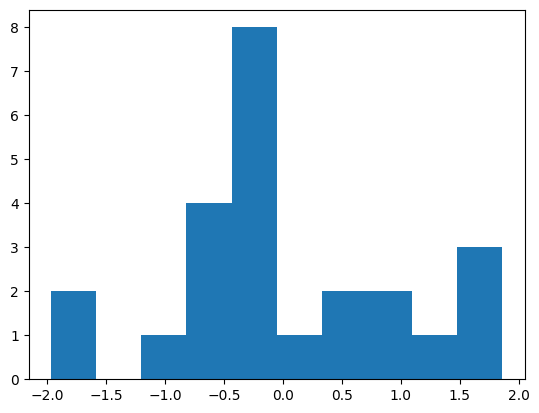

In [136]:
plt.hist(Tokyo2020[Tokyo2020['Javelin_Points'] != 0]['Javelin_Points'])

In [140]:
Tokyo2020.head()

,Rank,Country,Name,Final_Points,100m_hurdles_Result,100m_hurdles_Points,200m_Result,200m_Points,800m_Result,800m_Points,High_jump_Result,High_jump_Points,Javelin_Result,Javelin_Points,Long_jump_Result,Long_jump_Points,Shot_put_Result,Shot_put_Points
0,1.0,BEL,THIAM Nafissatou,6791.0,13.54,-0.355536,24.90,-1.197835,2:15.98,-0.313046,1.92,2.629760,54.68,1.858299,6.60,2.254232,14.82,1.235192
1,2.0,NED,VETTER Anouk,6689.0,13.09,1.245868,23.81,1.284184,2:18.72,-0.890978,1.80,0.044074,51.20,1.102193,6.47,1.579727,15.29,1.739851
2,3.0,NED,OOSTERWEGEL Emma,6590.0,13.36,0.289806,24.25,0.272098,2:11.09,0.751565,1.80,0.044074,54.60,1.836061,6.29,0.685616,13.28,-0.441576
3,4.0,BEL,VIDTS Noor,6571.0,13.17,0.959050,23.70,1.549254,2:09.05,1.207827,1.83,0.682101,41.80,-0.910386,6.32,0.826791,14.33,0.697975
4,5.0,USA,WILLIAMS Kendell,6508.0,12.97,1.676096,24.00,0.850433,2:16.91,-0.510760,1.80,0.044074,48.78,0.579589,6.57,2.097370,12.41,-1.385776


In [141]:
Tokyo2020['Javelin_Points'].mean()

-1.850371707708594e-17

In [155]:
columns = ['100m_hurdles_Points', '200m_Points', '800m_Points', 'High_jump_Points', 'Javelin_Points', 'Long_jump_Points', 'Shot_put_Points']
labels = ['100m hurdles', '200m', '800m', 'High jump', 'Javelin', 'Long jump', 'Shot put']

pos_scores = []
pos_labels = []
neg_scores = []
neg_labels = []

for index in range(0, 7):
    score = Tokyo2020[Tokyo2020.Name == 'THIAM Nafissatou'].loc[0, columns[index]]
    if score > 0:
        pos_scores.append(score)
        pos_labels.append(labels[index])
    else:
        neg_scores.append(score)
        neg_labels.append(labels[index])

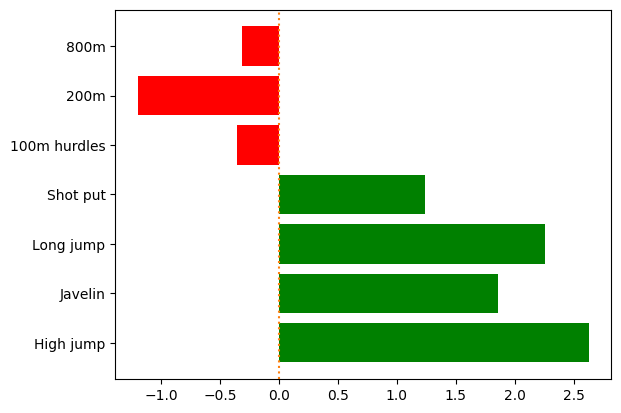

In [159]:
plt.barh(pos_labels, pos_scores, color='green')
plt.barh(neg_labels, neg_scores, color='red')
plt.axvline(0, zorder = 1, color = 'tab:orange', linestyle = "dotted")